## Experiment Tutorial: Two Qubits

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from qsopt.core.experimental_parameters import (
    ExperimentalParameters,
    PhysicalConstants,
    SystemDimensions,
    MeasurementProtocol,
    InteractionType,
    QubitInteraction,
    InitialStateConfig,
    InitialStateType,
    NoiseConfiguration
)
from qsopt.core.circuit import QuantumCircuit, create_ry_circuit_layer
from qsopt.core.experiment.experiment import Experiment

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## 1. Setup Experimental Parameters

In [2]:
# Define experimental parameters using nested configuration objects
interaction = QubitInteraction(
    qubit_indices=(0, 1),
    interaction_type=InteractionType.XX,
    chi=0.1
)

physical_constants = PhysicalConstants(
    n_qubits=2,
    chi=[30.0, 30.0],
    photon_cavity_coupling=15.0,
    inverse_pulse_width=1.0,
    qubit_interactions=[interaction]
)

system_dims = SystemDimensions(
    field_levels=2,
    cavity_levels=2,
    qubit_levels=[2, 2]
)

measurement = MeasurementProtocol(
    measurement_times=[-8.0, 8.0] 
)

initial_state = InitialStateConfig(state_type=InitialStateType.SINGLE_PHOTON)

noise_config = NoiseConfiguration(
    depolarizing=[0.0, 0.0],
    dephasing=[0.0, 0.0],
    relaxation=[0.0, 0.0]
)

exp_params = ExperimentalParameters(
    physical_constants=physical_constants,
    system_dims=system_dims,
    measurement=measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_params)

SYSTEM DIMENSIONS
  Number of qubits:          2
  Cavity levels:             2
  Qubit levels:         [2, 2]
  Field levels:              2
  Total dimension:          16
PHYSICAL CONSTANTS
  Chi:                  [30.0, 30.0]
  Photon cavity coupling: 15.0000
  Inverse pulse width:    1.0000
  Qubit interactions:   1 interaction(s)
    [0] Qubits (0, 1): sx-sx, χ=0.1000
MEASUREMENT PROTOCOL
  Mode:                 Explicit list
  Number of measurements:      2
  Measurement times:    [-8.0, 8.0]
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:    [0.0, 0.0]
  Dephasing rate:       [0.0, 0.0]
  Relaxation rate:      [0.0, 0.0]
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


## 2. Setup Trainable Parameters

For two-qubit experiments, we need 4 rotation angles:
- θ1_q1, θ2_q1: Rotation angles for qubit 1
- θ1_q2, θ2_q2: Rotation angles for qubit 2

In [3]:
# Create Circuit with 4 rotation angles

initial_circuit = create_ry_circuit_layer(n_qubits=2,\
        theta_values=np.pi/2)
final_circuit = create_ry_circuit_layer(n_qubits=2,\
        theta_values=-np.pi/2)

import optax
optimizer = optax.sgd(learning_rate=1.)

print(initial_circuit)
print(final_circuit)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


QuantumCircuit(2 qubits, 2 gates)
  0: RY(1.5708)[0][0]
  1: RY(1.5708)[1][1]
QuantumCircuit(2 qubits, 2 gates)
  0: RY(-1.5708)[0][0]
  1: RY(-1.5708)[1][1]


## 3. Create Two-Qubit Experiment

Initialize the experiment with our parameters. This will:
- Generate operators for the 4-subsystem composite space
- Build the time-dependent Hamiltonian
- Cache initial state and projectors

In [4]:
experiment = Experiment(exp_params, initial_circuit, final_circuit)

## 4. Run Basic Simulation

In [5]:
# Run simulation with zero rotations
callback = experiment.run_simulation(batch_size=1)

print(callback)

MODE: Single Simulation
  Current Parameters:
     Initial circuit:
        param_0: 1.570796 rad (90.00°)
        param_1: 1.570796 rad (90.00°)
     Final circuit:
        param_0: -1.570796 rad (-90.00°)
        param_1: -1.570796 rad (-90.00°)
  Detection Probabilities:
     P(with photon):    0.991624
     P(without photon): 0.000000
     Contrast:          0.991624


## 5. Optimize Rotation Angles

Now let's optimize the four rotation angles to maximize sensing contrast. By default, the optimization maximizes the detection probability `1 - P(00)` (any outcome except ground state).


In [6]:
# Optimize with default detection criterion (1 - P(00))
callback_opt = experiment.optimize_rotations(
    num_steps=10,
    batch_size=1,
    tolerance=1e-8,
    verbose=True,
    verbose_step=1,
    initial_values=[np.pi/3, np.pi/4,-np.pi/3, -np.pi]
)


Configuration:
    Max iterations: 10
    Batch size: 1
    Convergence tolerance: 1.00e-08
    Detection criterion: 1 - P(0)
    Trainable parameters: 4 (2 initial circuit + 2 final circuit)
    Initial parameter values:
        initial_param_0=1.047 rad (60.0°)
        initial_param_1=0.785 rad (45.0°)
        final_param_2=-1.047 rad (-60.0°)
        final_param_3=-3.142 rad (-180.0°)
Step  init_0      init_1      final_0     final_1     Contrast    Grad Norm
---------------------------------------------------------------------------
0     1.047198    0.785398    -1.047198   -3.141593   0.124653    5.05e-01    
1     1.050423    0.939616    -1.071693   -2.943092   0.270848    6.42e-01    
2     1.059938    1.145829    -1.087320   -2.697725   0.490755    7.05e-01    
3     1.074148    1.376659    -1.096446   -2.431740   0.728110    6.14e-01    
4     1.089620    1.576684    -1.102766   -2.199683   0.888015    4.13e-01    
5     1.103138    1.706767    -1.109408   -2.040168   0.955152

### Visualize Optimization Progress

Let's plot how the contrast evolved during optimization:


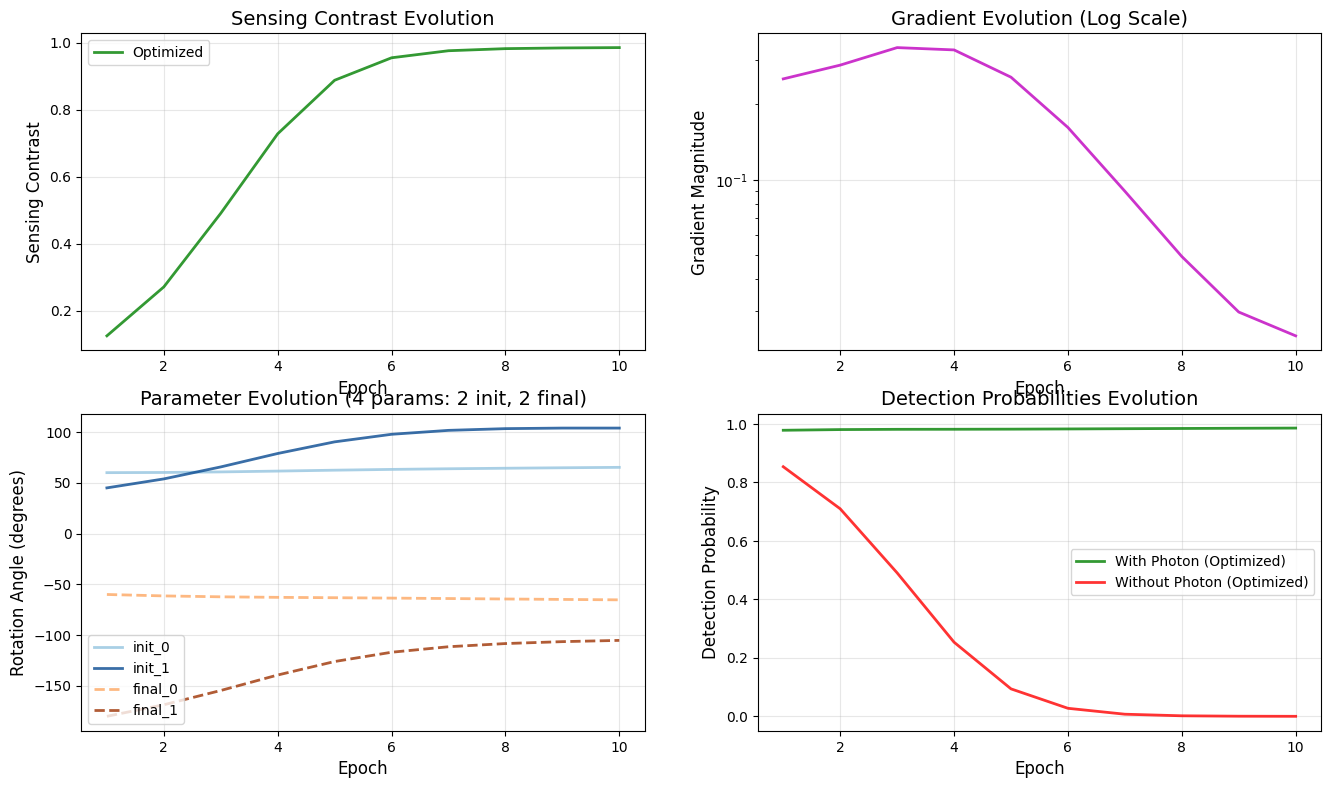

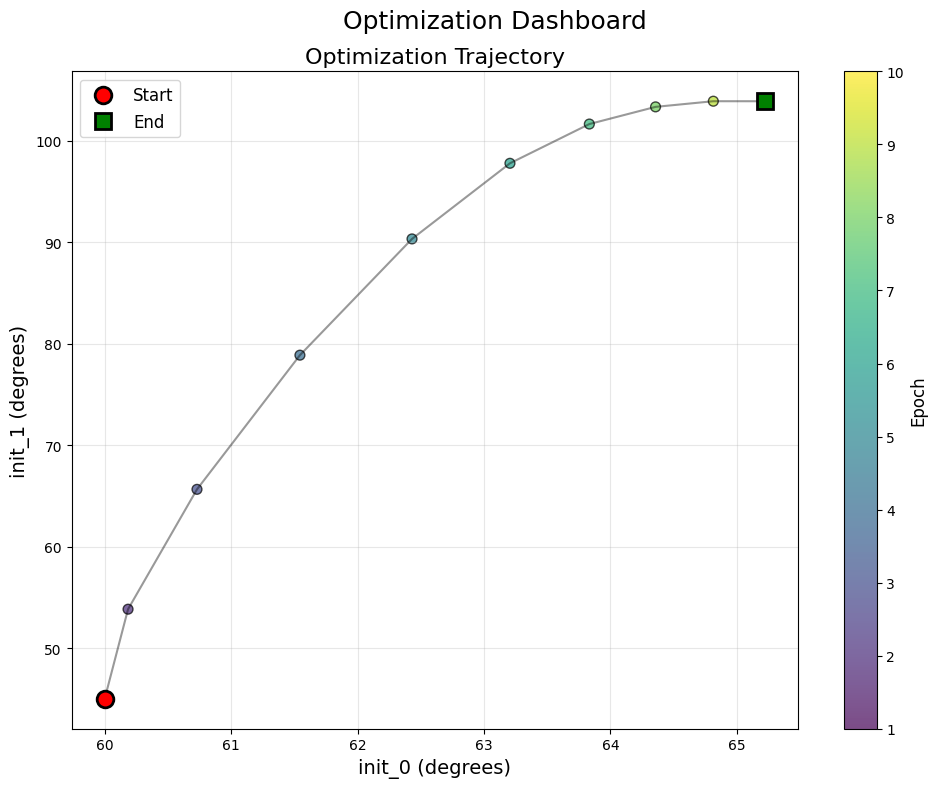

In [7]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard showing all optimization metrics
fig = plot_optimization_dashboard(
    callback_opt,
    show_contrast=True,
    show_gradients=True,
    show_parameters=True,
    show_trajectory=True,
    show_probabilities=True,
    figsize=(16, 14)
)
plt.show()
